In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split


In [2]:
df = pd.read_csv("csv/trainExtended_morgan1812.csv")

df = df.dropna()

test_df = pd.read_csv("melting-point-data/morganfeatures_test.csv")
ids = test_df["id"].tolist()
test_df = test_df.drop(["Unnamed: 0", "id", "SMILES"], axis = 1)
X_test = np.array(test_df)

In [3]:
X = np.array(df.drop(["SMILES", "Tm"], axis = 1))
y = np.array(df["Tm"]).reshape(-1,1)

# X_train, X_test, y_train, y_test = train_test_split(X,y, random_state= 42, test_size=0.3)

X_test

array([[11.05212113, 11.05212113,  0.14171155, ...,  1.        ,
         1.        ,  0.        ],
       [ 9.48787454,  9.48787454,  0.1248224 , ...,  1.        ,
         1.        ,  0.        ],
       [ 4.91512346,  4.91512346,  0.53472222, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 5.02680556,  5.02680556,  0.76023148, ...,  0.        ,
         0.        ,  0.        ],
       [ 3.44733796,  3.44733796,  0.54803241, ...,  0.        ,
         0.        ,  0.        ],
       [ 8.52757086,  8.52757086,  0.28660147, ...,  1.        ,
         1.        ,  0.        ]], shape=(666, 2432))

In [6]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import numpy as np
import xgboost as xgb





def residual_cv_fast(X, y, X_test, n_splits=3, seed=42):
    y = np.asarray(y).ravel()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    base_params = dict(
        n_estimators=30000, learning_rate=0.01, max_depth=7,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        objective="reg:absoluteerror", tree_method="hist",
        n_jobs=-1, random_state=seed
    )
    resid_params = dict(
        n_estimators=16000, learning_rate=0.01, max_depth=4,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
        objective="reg:absoluteerror", tree_method="hist",
        n_jobs=-1, random_state=seed
    )

    oof_base = np.zeros(len(y))
    test_base_folds = []

    w = np.where(y > 450, 2.0, 1.0)
    for tr, va in kf.split(X):
        m = xgb.XGBRegressor(**base_params)
        m.fit(X[tr], y[tr], sample_weight = w[tr])
        oof_base[va] = m.predict(X[va])
        test_base_folds.append(m.predict(X_test))

    base_mae = mean_absolute_error(y, oof_base)
    print("Base OOF MAE:", base_mae)

    resid_target = y - oof_base
    oof_resid = np.zeros(len(y))
    test_resid_folds = []

    for tr, va in kf.split(X):
        r = xgb.XGBRegressor(**resid_params)
        r.fit(X[tr], resid_target[tr])
        oof_resid[va] = r.predict(X[va])
        test_resid_folds.append(r.predict(X_test))

    oof_final = oof_base + oof_resid
    final_mae = mean_absolute_error(y, oof_base + oof_resid)
    print("2-Stage OOF MAE:", final_mae)

    test_pred = np.mean(test_base_folds, axis=0) + np.mean(test_resid_folds, axis=0)
    return test_pred, oof_base, oof_final


In [7]:
test_pred, oof_base, oof_final = residual_cv_fast(X, y, X_test, n_splits=3, seed=42)

Base OOF MAE: 27.554842323460473
2-Stage OOF MAE: 30.451337961803194


In [13]:
# submission = pd.DataFrame({"id": ids, "Tm": y_test_pred})
# submission.to_csv("submission.csv", index=False)

y


array([[213.15],
       [407.15],
       [324.15],
       ...,
       [433.15],
       [469.15],
       [573.15]], shape=(2814, 1))

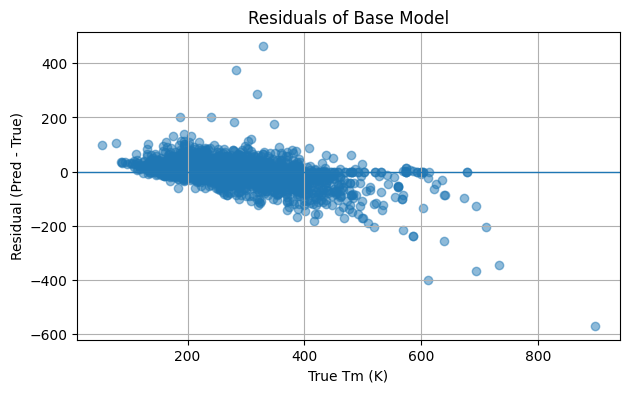

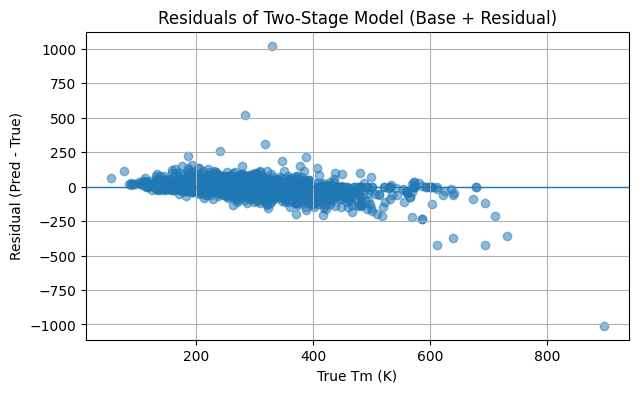

In [14]:
import matplotlib.pyplot as plt

# test_pred, oof_base, oof_final = residual_cv_fast(X, y, X_test, n_splits=3)
y = y.ravel()
res_base  = oof_base  - y
res_final = oof_final - y

plt.figure(figsize=(7,4))
plt.scatter(y, res_base, alpha=0.5)
plt.axhline(0, linewidth=1)
plt.xlabel("True Tm (K)")
plt.ylabel("Residual (Pred - True)")
plt.title("Residuals of Base Model")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,4))
plt.scatter(y, res_final, alpha=0.5)
plt.axhline(0, linewidth=1)
plt.xlabel("True Tm (K)")
plt.ylabel("Residual (Pred - True)")
plt.title("Residuals of Two-Stage Model (Base + Residual)")
plt.grid(True)
plt.show()
